# 10 - Models 3 and 4: follow-up checks
Five checks on the final BiLSTM (notebook 03) and Transformer (notebook 04) configs. They add evidence about **whether these models use word order** and **how stable and well calibrated they are**. Nothing here changes `reports/results.csv` or `reports/predictions/`.

| Check | Question | How |
|---|---|---|
| T6 | Does positional encoding help the **final** Transformer config? | T1 compared positions before GloVe initialisation (T4) was added. T6 repeats none / sinusoidal / learned on the final config, 3 seeds |
| Shuffle | Do the trained models actually use word order? | Test macro-F1 on the original tweets vs the same tweets with their words shuffled (5 shuffles) |
| Seeds | How much does the test score depend on the training seed? | Final config trained with seeds 42, 1, 2 and evaluated on test (the config is already fixed, so this is not tuning on test) |
| ROC / PR | How well do the predicted probabilities rank each class? | One-vs-rest ROC and precision-recall curves on test |
| Offset | Can the BiLSTM find more anti-vaccine tweets without retraining? | A log-probability offset for the negative class, tuned on validation and applied once to test |

Seed 42 is the official model. If `models/<name>.pt` exists (saved by notebooks 03 and 04) it is loaded; otherwise the config is retrained with seed 42, and the cell below reports how closely its test predictions match the saved ones.

**Runtime:** about 1 h on a laptop CPU, about 10 min on a Colab T4 GPU. Needs the GloVe cache from notebook 03.

In [1]:
import os, sys

if "google.colab" in sys.modules:
    %pip install -q emoji
    from google.colab import drive
    drive.mount("/content/drive")
    BASE = "/content/drive/MyDrive/formative2-vaccine-sentiment"
    GLOVE_DIR = "/content/glove"
else:
    BASE = os.path.abspath(os.path.join(os.getcwd(), "..")) if os.path.basename(os.getcwd()) == "notebooks" else os.getcwd()
    GLOVE_DIR = os.path.join(BASE, "data/embeddings/raw")

os.chdir(BASE)
sys.path.insert(0, BASE)
print("Working directory:", os.getcwd())

Working directory: formative2-vaccine-sentiment


In [2]:
import numpy as np, pandas as pd, torch
import matplotlib.pyplot as plt, seaborn as sns
from IPython.display import display
from sklearn.metrics import accuracy_score, f1_score, mean_squared_error, precision_recall_fscore_support
from src.preprocessing import load_splits
from src.evaluation import LABELS, save_probabilities, plot_roc_pr, tune_class_offset, apply_class_offset
from src.nn_utils import (DEVICE, Vocab, make_datasets, make_loaders, class_weights, load_glove_subset,
                          embedding_matrix, fit, predict, shuffle_test)
from src.models import BiLSTMClassifier, TransformerClassifier
from src.experiments import Experiments, plot_sweep
from src.analysis import negation_mask

sns.set_theme(style="whitegrid")
FIG, AUTHOR = "reports/figures/", "P2"
BILSTM, TRANSFORMER = "bilstm_glove", "transformer_scratch"
SEEDS = (42, 1, 2)
print("Device:", DEVICE)

train, val, test = load_splits()
CW = class_weights(train)
vocab = Vocab(train["clean_text"], min_freq=2)
datasets = make_datasets(train, val, test, vocab)          # word tokens, MAX_LEN 40, as in notebooks 03 and 04
EMB100 = embedding_matrix(vocab, load_glove_subset(100, train["clean_text"], glove_dir=GLOVE_DIR), 100)
_, VAL_DL, TEST_DL = make_loaders(datasets)

Device: cpu


## Final configs and runners
The configs are the winners of notebooks 03 (L1-L5) and 04 (T1-T5), and the training functions are the same as there.

In [3]:
FINAL = {
    BILSTM: dict(emb="glove", freeze=False, dim=100, hidden=256, bidirectional=True,
                 pooling="attention", dropout=0.5, lr=1e-3, weighted=False),
    TRANSFORMER: dict(tok="word", emb="glove", d_model=100, n_layers=2, n_heads=4, dropout=0.2,
                      pos="none", pooling="cls", lr=5e-4, warmup=0.1),
}


def build_bilstm(cfg):
    assert cfg["emb"] == "glove" and cfg["dim"] == 100
    return BiLSTMClassifier(len(vocab), cfg["dim"], cfg["hidden"], bidirectional=cfg["bidirectional"],
                            pooling=cfg["pooling"], dropout=cfg["dropout"], freeze=cfg["freeze"], embeddings=EMB100)


def build_transformer(cfg):
    assert cfg["tok"] == "word" and cfg["emb"] == "glove" and cfg["d_model"] == 100
    return TransformerClassifier(len(vocab), cfg["d_model"], cfg["n_heads"], cfg["n_layers"],
                                 ff_dim=2 * cfg["d_model"], dropout=cfg["dropout"], pos=cfg["pos"],
                                 pooling=cfg["pooling"], embeddings=EMB100)


def train_bilstm(cfg, seed, verbose=False):
    train_dl, val_dl, _ = make_loaders(datasets, seed=seed)
    model = build_bilstm(cfg)
    hist, best = fit(model, train_dl, val_dl, val["label"], epochs=20, patience=5, lr=cfg["lr"],
                     class_weights=CW if cfg["weighted"] else None, verbose=verbose)
    return model, hist, best


def train_transformer(cfg, seed, verbose=False):
    train_dl, val_dl, _ = make_loaders(datasets, seed=seed)
    model = build_transformer(cfg)
    hist, best = fit(model, train_dl, val_dl, val["label"], epochs=30, patience=5, lr=cfg["lr"],
                     weight_decay=0.01, warmup=cfg["warmup"], class_weights=CW, verbose=verbose)
    return model, hist, best


BUILD = {BILSTM: build_bilstm, TRANSFORMER: build_transformer}
ex = {BILSTM: Experiments(train_bilstm, BILSTM, FINAL[BILSTM], seeds=SEEDS, author=AUTHOR),
      TRANSFORMER: Experiments(train_transformer, TRANSFORMER, FINAL[TRANSFORMER], seeds=SEEDS, author=AUTHOR)}

## T6: positional encoding on the final Transformer config
T1 chose `pos="none"` with random embeddings and d_model 128. Every later experiment was built on that choice, so it was never re-tested once GloVe initialisation (T4), the change that clearly helped, was added. T6 re-tests it on the final config. It is a validation experiment like T1-T5, with the same 3 seeds and the same rule for comparing gaps with seed noise.

,pos,val_macro_f1,f1_std,val_rmse,rmse_std,best_epoch,n_params
0,none,0.6323,0.0105,0.6594,0.0069,13.6667,672803
1,sinusoidal,0.6287,0.0086,0.6381,0.0360,16.3333,672803
2,learned,0.6129,0.0234,0.6328,0.0197,13.0000,698403


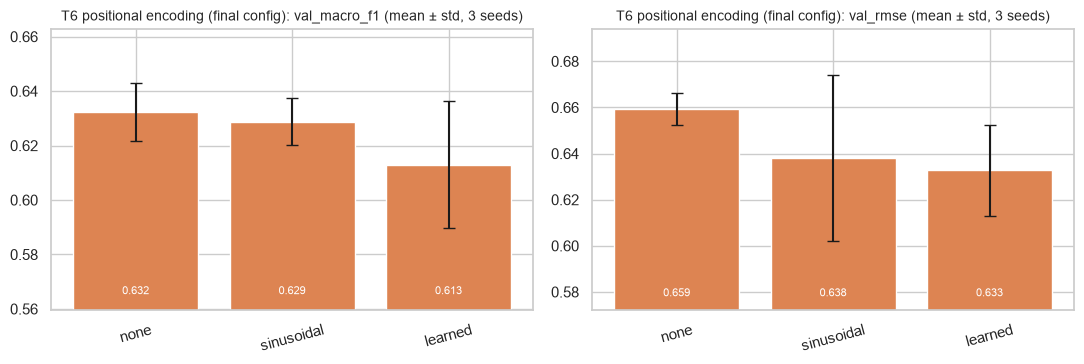

T6 winner: pos=none (0.6323), leads pos=sinusoidal by 0.0036; seed std 0.0105 -> within seed noise
Best order-aware variant (used in the shuffle test): sinusoidal


In [4]:
t6 = ex[TRANSFORMER].sweep("T6", [dict(pos="none"), dict(pos="sinusoidal"), dict(pos="learned")])
plot_sweep(t6, "pos", "T6 positional encoding (final config)", FIG + "t6_transformer_positions_final.png", color="#dd8452")

d = t6.sort_values("val_macro_f1", ascending=False).reset_index(drop=True)
gap, noise = d.loc[0, "val_macro_f1"] - d.loc[1, "val_macro_f1"], max(d.loc[0, "f1_std"], d.loc[1, "f1_std"])
print(f"T6 winner: pos={d.loc[0, 'pos']} ({d.loc[0, 'val_macro_f1']:.4f}), leads pos={d.loc[1, 'pos']} by {gap:.4f}; "
      f"seed std {noise:.4f} -> {'clear difference' if gap > noise else 'within seed noise'}")
ORDER_AWARE = t6[t6["pos"] != "none"].sort_values("val_macro_f1").iloc[-1]["pos"]
print("Best order-aware variant (used in the shuffle test):", ORDER_AWARE)

## The official (seed-42) models

In [5]:
def official_model(name):
    path = f"models/{name}.pt"
    if os.path.exists(path):
        model = BUILD[name](FINAL[name]).to(DEVICE)
        model.load_state_dict(torch.load(path, map_location=DEVICE))
        source = "saved checkpoint"
    else:
        model, source = ex[name].run("S1", seed=42)[1], "retrained with seed 42"
    yp = predict(model, TEST_DL)[0]
    saved = pd.read_csv(f"reports/predictions/{name}.csv")
    assert list(saved["tweet_id"]) == list(test["tweet_id"])
    agree = (yp == saved["y_pred"].to_numpy()).mean()
    print(f"{name}: {source}; test predictions identical to reports/predictions/{name}.csv on {agree:.1%} of tweets, "
          f"test macro-F1 {f1_score(test['label'], yp, average='macro'):.4f}")
    return model


OFFICIAL = {name: official_model(name) for name in (BILSTM, TRANSFORMER)}

bilstm_glove: retrained with seed 42; test predictions identical to reports/predictions/bilstm_glove.csv on 90.2% of tweets, test macro-F1 0.6295


transformer_scratch: retrained with seed 42; test predictions identical to reports/predictions/transformer_scratch.csv on 83.7% of tweets, test macro-F1 0.6239


## Shuffle test: do the trained models use word order?
Each test tweet keeps its words but in a random order (5 different shuffles). A model that reads the tweet as a bag of words scores the same on both versions. The final Transformer has no positional encoding, so its drop is zero by construction; it is included as a check of the test. The best order-aware Transformer from T6 (seed 42) shows whether positions make the model rely on order. Tweets with negation are scored separately, because that is where the EDA expected word order to matter most.

,model,slice,n,original,shuffled,shuffled_std,drop
0,bilstm_glove,all,1434,0.6295,0.6029,0.0031,0.0266
1,bilstm_glove,negation,366,0.5855,0.5554,0.0097,0.0301
2,"transformer_scratch (pos=none, final)",all,1434,0.6239,0.6239,0.0000,0.0000
3,"transformer_scratch (pos=none, final)",negation,366,0.6282,0.6282,0.0000,0.0000
4,transformer_scratch (pos=sinusoidal),all,1434,0.6481,0.6441,0.0041,0.0039
5,transformer_scratch (pos=sinusoidal),negation,366,0.6039,0.6069,0.0078,-0.0030


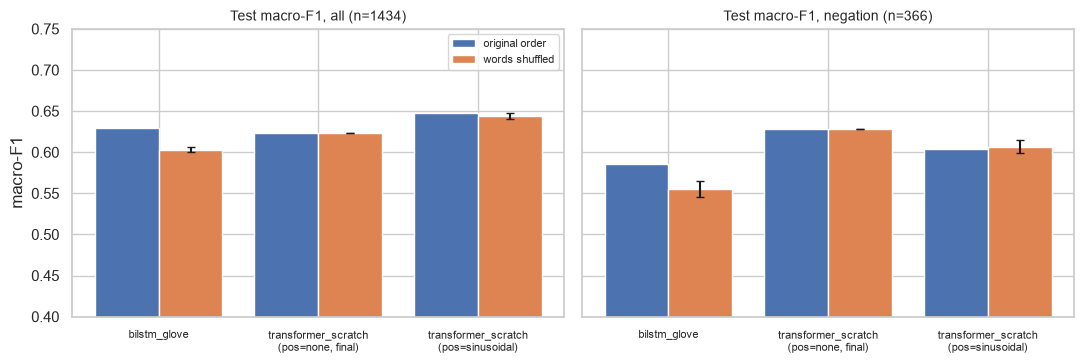

In [6]:
NEG = negation_mask(test["safe_text"]).to_numpy()
test_ds = datasets[2]
models = {BILSTM: OFFICIAL[BILSTM],
          f"{TRANSFORMER} (pos=none, final)": OFFICIAL[TRANSFORMER],
          f"{TRANSFORMER} (pos={ORDER_AWARE})": ex[TRANSFORMER].run("T6", seed=42, pos=ORDER_AWARE)[1]}

shuf = pd.concat([shuffle_test(m, test_ds, test["label"], n_shuffles=5, masks={"negation": NEG}).assign(model=name)
                  for name, m in models.items()], ignore_index=True)
shuf = shuf[["model", "slice", "n", "original", "shuffled", "shuffled_std", "drop"]]
shuf.round(4).to_csv("reports/shuffle_test.csv", index=False)
display(shuf.round(4))

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), sharey=True)
for ax, sl in zip(axes, ["all", "negation"]):
    s = shuf[shuf["slice"] == sl]
    x = np.arange(len(s))
    ax.bar(x - 0.2, s["original"], 0.4, label="original order", color="#4c72b0")
    ax.bar(x + 0.2, s["shuffled"], 0.4, yerr=s["shuffled_std"], capsize=3, label="words shuffled", color="#dd8452")
    ax.set_xticks(x, [m.replace(" (", "\n(") for m in s["model"]], fontsize=8)
    ax.set_title(f"Test macro-F1, {sl} (n={s['n'].iloc[0]})", fontsize=10)
    ax.set_ylim(0.4, 0.75)
axes[0].set_ylabel("macro-F1"); axes[0].legend(fontsize=8)
plt.tight_layout(); plt.savefig(FIG + "shuffle_test.png", dpi=200); plt.show()

## Seeds: test scores of the final configs with three training seeds
Seed 42 is the official model reported everywhere else. Seeds 1 and 2 are evaluated only to show how much the test score moves with the training seed; they are not used for any choice.

In [7]:
def test_row(model):
    yp, ys, _ = predict(model, TEST_DL)
    _, r, f, _ = precision_recall_fscore_support(test["label"], yp, labels=LABELS, zero_division=0)
    return dict(macro_f1=f1_score(test["label"], yp, average="macro"),
                rmse=float(np.sqrt(mean_squared_error(test["label"], ys))),
                accuracy=accuracy_score(test["label"], yp), f1_negative=f[0], recall_negative=r[0])


seed_rows = pd.DataFrame([dict(model=name, seed=s, **test_row(OFFICIAL[name] if s == 42 else ex[name].run("S1", seed=s)[1]))
                          for name in (BILSTM, TRANSFORMER) for s in SEEDS])
seed_rows.round(4).to_csv("reports/test_seed_stability.csv", index=False)
display(seed_rows.round(4))
metrics = ["macro_f1", "rmse", "accuracy", "f1_negative", "recall_negative"]
seed_summary = seed_rows.groupby("model", sort=False)[metrics].agg(["mean", "std"]).round(4)
display(seed_summary)

,model,seed,macro_f1,rmse,accuracy,f1_negative,recall_negative
0,bilstm_glove,42,0.6295,0.5898,0.7336,0.3581,0.2697
1,bilstm_glove,1,0.6388,0.5876,0.7329,0.3843,0.3224
2,bilstm_glove,2,0.6555,0.5669,0.7392,0.4280,0.3618
3,transformer_scratch,42,0.6239,0.6693,0.6897,0.4165,0.5329
4,transformer_scratch,1,0.6515,0.6468,0.7106,0.4567,0.5724
5,transformer_scratch,2,0.6375,0.6496,0.7008,0.4246,0.5461


macro_f1            rmse         accuracy          \
                        mean     std    mean     std     mean     std   
model                                                                   
bilstm_glove          0.6412  0.0132  0.5814  0.0126   0.7352  0.0034   
transformer_scratch   0.6376  0.0138  0.6553  0.0123   0.7004  0.0105   

                    f1_negative         recall_negative          
                           mean     std            mean     std  
model                                                            
bilstm_glove             0.3901  0.0353          0.3180  0.0462  
transformer_scratch      0.4326  0.0213          0.5504  0.0201

## ROC and precision-recall curves
One-vs-rest curves from the official models' test probabilities. Precision-recall is the more informative view for the negative class, which is only 10.6% of the test set (dashed line = precision of a random classifier). The probabilities are saved in `reports/probabilities/` for later use.

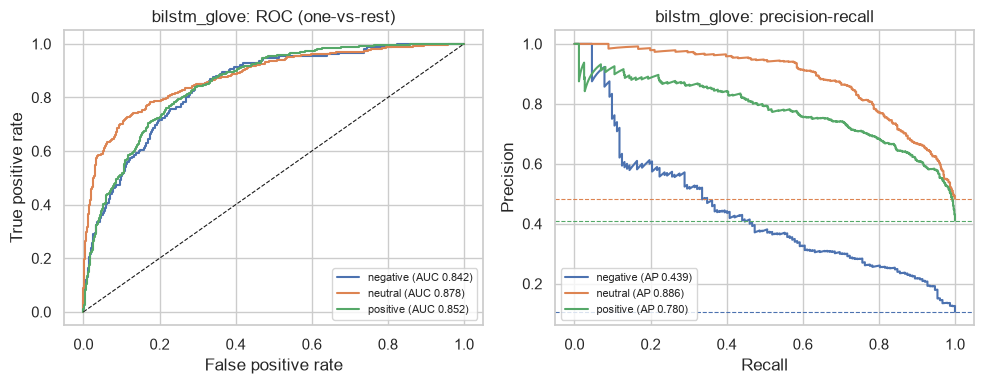

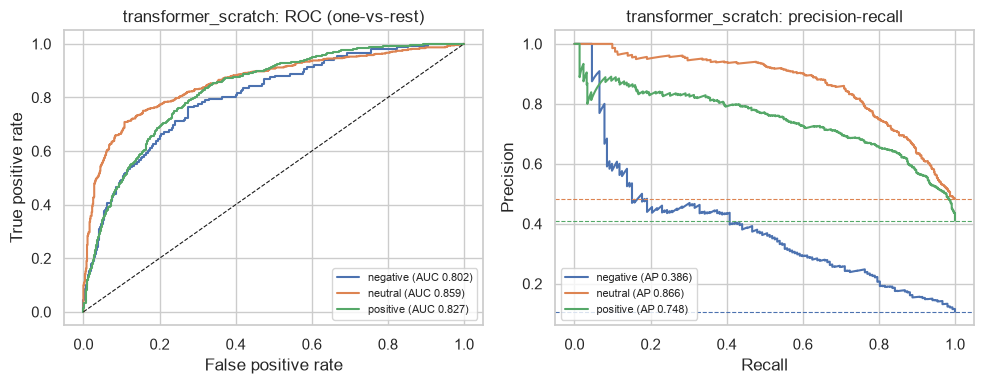

roc_auc                  average_precision          \
cls                 negative neutral positive          negative neutral   
model                                                                     
bilstm_glove          0.8423  0.8783   0.8515            0.4389  0.8858   
transformer_scratch   0.8021  0.8586   0.8270            0.3860  0.8665   

                              
cls                 positive  
model                         
bilstm_glove          0.7805  
transformer_scratch   0.7477

In [8]:
auc_rows = []
for name in (BILSTM, TRANSFORMER):
    _, _, P = predict(OFFICIAL[name], TEST_DL)
    save_probabilities(name, test["tweet_id"], test["label"], P)
    for cls, (auc, ap) in plot_roc_pr(test["label"], P, name).items():
        auc_rows.append(dict(model=name, cls=cls, roc_auc=auc, average_precision=ap))
auc_table = pd.DataFrame(auc_rows).pivot(index="model", columns="cls", values=["roc_auc", "average_precision"])
auc_table.round(4).to_csv("reports/roc_pr_auc.csv")
display(auc_table.round(4))

## Offset: more negative predictions from the BiLSTM without retraining
The BiLSTM was trained without class weights (L3), so it finds few anti-vaccine tweets. Here a constant is added to the negative class's log-probability. The constant is tuned on **validation** macro-F1 and then applied **once** to test. This is a post-hoc decision rule on top of the official model, so its result is reported separately and does not replace the official BiLSTM numbers.

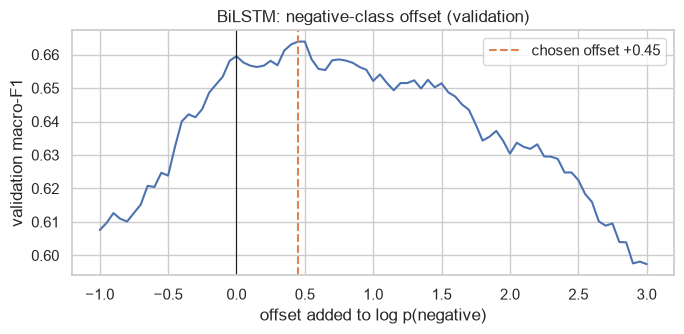

Validation macro-F1: offset 0 -> 0.6595, offset +0.45 -> 0.6639


,rule,macro_f1,rmse,accuracy,precision_negative,recall_negative,f1_negative,f1_neutral,f1_positive
0,official (argmax),0.6295,0.5898,0.7336,0.5325,0.2697,0.3581,0.7912,0.7392
1,negative offset +0.45,0.6400,0.5871,0.7315,0.4679,0.3355,0.3908,0.7908,0.7384


In [9]:
m = OFFICIAL[BILSTM]
_, _, P_val = predict(m, VAL_DL)
yp_test, ys_test, P_test = predict(m, TEST_DL)
best_offset, offset_table = tune_class_offset(P_val, val["label"], cls=-1)

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(offset_table["offset"], offset_table["macro_f1"], color="#4c72b0")
ax.axvline(0, color="k", lw=0.8); ax.axvline(best_offset, color="#dd8452", ls="--", label=f"chosen offset {best_offset:+.2f}")
ax.set(xlabel="offset added to log p(negative)", ylabel="validation macro-F1", title="BiLSTM: negative-class offset (validation)")
ax.legend(); plt.tight_layout(); plt.savefig(FIG + "negative_offset_bilstm.png", dpi=200); plt.show()


def rule_row(rule, yp, ys):
    p, r, f, _ = precision_recall_fscore_support(test["label"], yp, labels=LABELS, zero_division=0)
    return dict(rule=rule, macro_f1=f1_score(test["label"], yp, average="macro"),
                rmse=float(np.sqrt(mean_squared_error(test["label"], ys))), accuracy=accuracy_score(test["label"], yp),
                precision_negative=p[0], recall_negative=r[0], f1_negative=f[0], f1_neutral=f[1], f1_positive=f[2])


yp_off, ys_off, _ = apply_class_offset(P_test, best_offset, cls=-1)
offset_val = offset_table.set_index("offset").loc[[0.0, best_offset], "macro_f1"]
print(f"Validation macro-F1: offset 0 -> {offset_val.iloc[0]:.4f}, offset {best_offset:+.2f} -> {offset_val.iloc[1]:.4f}")
posthoc = pd.DataFrame([rule_row("official (argmax)", yp_test, ys_test),
                        rule_row(f"negative offset {best_offset:+.2f}", yp_off, ys_off)])
posthoc.round(4).to_csv("reports/posthoc_negative_offset.csv", index=False)
display(posthoc.round(4))

## Summary
**Which models were used.** `models/*.pt` was not available on the machine that ran this notebook (CPU), so the seed-42 models were retrained. CPU training does not reproduce the Colab GPU runs exactly: the retrained models agree with the saved test predictions on 90.2% (BiLSTM) and 83.7% (Transformer) of tweets, and score 0.630 and 0.624 test macro-F1 against the official 0.650 and 0.654. The shuffle, ROC/PR and offset results therefore describe a model with the final config, not the exact official one. Running this notebook on Colab with the saved checkpoints ties them to the official models.

- **T6 (positions on the final config):** none 0.632 (std 0.011), sinusoidal 0.629 (0.009), learned 0.613 (0.023). The 0.004 lead of "none" is inside the seed noise, as in T1. With GloVe initialisation, positional information still gives no measurable benefit, so the final Model 4 is unchanged. Sinusoidal has a lower mean RMSE (0.638 vs 0.659), but its RMSE std is 0.036.
- **Shuffle test:** shuffling the words lowers the BiLSTM's test macro-F1 by 0.027 (0.630 to 0.603) and by 0.030 on tweets with negation, so the BiLSTM does use some word order. The final Transformer loses exactly 0, as it must without positions. The sinusoidal Transformer loses only 0.004 overall and nothing on negation: even when it is given positions, the Transformer trained on 6.7k tweets barely uses them. Of the two models trained from scratch, only the recurrent one learns an order-dependent signal, and it is small.
- **Seeds on test:** BiLSTM 0.641 ± 0.013 (range 0.630-0.656), Transformer 0.638 ± 0.014 (0.624-0.652). The spread across training seeds (about 0.03) is several times the gap between TF-IDF, BiLSTM and Transformer on test (0.005), so Models 1, 3 and 4 cannot be ranked. The official Colab seed-42 scores (0.650, 0.654) are at the upper end of these ranges. The BiLSTM is the more accurate model (0.735 vs 0.700) with the lower RMSE (0.581 vs 0.655). The class-weighted Transformer finds far more negatives (recall 0.550 vs 0.318).
- **ROC / PR:** the BiLSTM ranks every class better than the Transformer (ROC AUC negative 0.842 vs 0.802, neutral 0.878 vs 0.859, positive 0.852 vs 0.827). For the negative class the average precision is 0.439 vs 0.386, about four times the 0.106 of a random ranking, but precision falls below 0.6 beyond about 20% recall. The BiLSTM ranks negatives better than the Transformer yet recalls fewer of them, so its low negative recall is mostly a decision-threshold problem.
- **Negative-class offset (BiLSTM):** an offset of +0.45, chosen on validation (macro-F1 0.660 to 0.664), raises test macro-F1 from 0.630 to 0.640, negative recall from 0.270 to 0.336 and negative F1 from 0.358 to 0.391. Negative precision falls from 0.533 to 0.468, and the neutral and positive F1 scores barely change. The validation gain is small (0.004), so this is a modest, post-hoc improvement and is not used in place of the official BiLSTM results.
